In [1]:
import cv2
import numpy as np

import matplotlib.pyplot as plt
np.seterr(over='raise')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

Procesamiento de Brillo

In [2]:
def contraste_brillo(imagen, contraste, brillo):
    imagen_procesada = np.zeros_like(imagen)
    h,w = imagen.shape
    for y in range(h):
        for x in range(w):
            try:
                imagen_procesada[y,x] = np.clip(contraste * imagen[y,x] + brillo, 0, 255).astype(np.uint8)
            except FloatingPointError as e:
                imagen_procesada[y,x] = 255
    return imagen_procesada

In [69]:
ruta = "img1/FotoOs.png"
imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
h,w = imagen.shape
imagen_procesada = contraste_brillo(imagen, 1, 90)
imagenes_comparadas = np.hstack((imagen, imagen_procesada))
cv2.imshow("Comparacion", imagenes_comparadas)
cv2.waitKey(0)

-1

In [70]:
hist = cv2.calcHist([imagen_procesada],[0], None, [255], [0, 255])
hist

array([[0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.0000e+00],
       [0.000

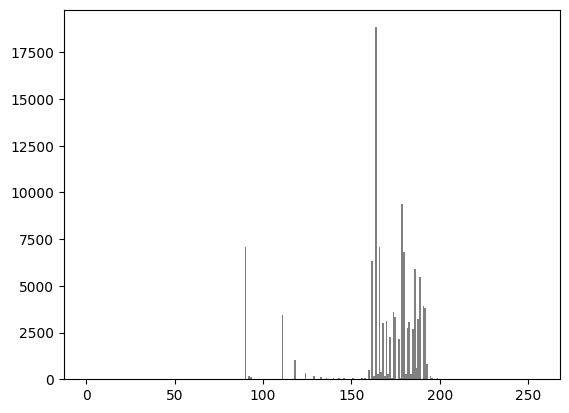

In [71]:
h, w = imagen.shape
numero_de_pixeles = w * h

# Funcion de distribució acumulada
def FDA(numero_de_pixeles, hist, I):
    acum = 0
    for i in range(I):
        acum = acum + hist[i][0]
    return acum/numero_de_pixeles

FDA(numero_de_pixeles, hist, 128)

plt.hist(imagen_procesada.flatten(), bins=256, range=(0,255), color="gray")
plt.show()

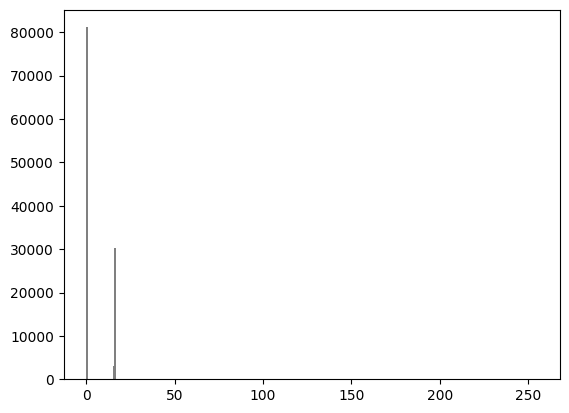

-1

In [72]:
imagen_ecualizada = np.zeros_like(imagen)
for y in range(h):
    for x in range(w):
        imagen_ecualizada[y,x] = 255 * FDA(numero_de_pixeles, hist, imagen[y,x])
imagen_mostrar = np.hstack((imagen, imagen_ecualizada))
plt.hist(imagen_ecualizada.flatten(), bins=256, range=(0,255), color="gray")
plt.show()
cv2.imshow("Imagenes", imagen_mostrar)
cv2.waitKey(0)



Procesamiento de contraste

In [74]:
ruta = "img1/FotoOs.png"
imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
h,w = imagen.shape

imagen_procesada = contraste_brillo(imagen, 1, 90)
imagenes_comparadas = np.hstack((imagen, imagen_procesada))
cv2.imshow("Comparacion", imagenes_comparadas)
cv2.waitKey(0)

-1

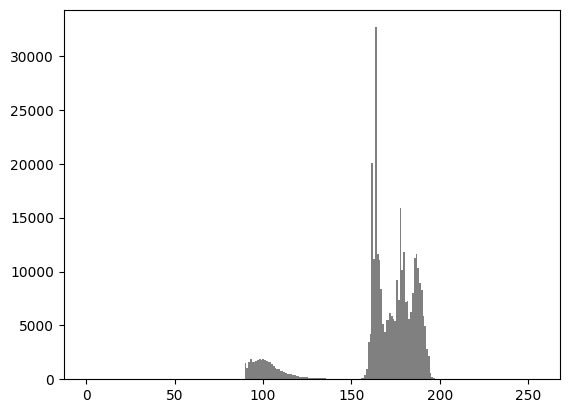

In [76]:
imagen_color = cv2.imread(ruta)
def contraste_brillo_mat(imagen, contraste, brillo):
    imagen_p = imagen.astype(np.float32)
    return np.clip(contraste * imagen_p + brillo, 0, 255).astype(np.uint8)

imagen_color_procesada = contraste_brillo_mat(imagen_color, 1,90)
imagen_mostrar = np.hstack((imagen_color, imagen_color_procesada))
cv2.imshow("Imagen a color procesada", imagen_mostrar)
cv2.waitKey(0)
h, w = imagen.shape
numero_de_pixeles = w * h

# Funcion de distribució acumulada
def FDA(numero_de_pixeles, hist, I):
    acum = 0
    for i in range(I):
        acum = acum + hist[i][0]
    return acum/numero_de_pixeles

FDA(numero_de_pixeles, hist, 255)

plt.hist(imagen_color_procesada.flatten(), bins=256, range=(0,255), color="gray")
plt.show()

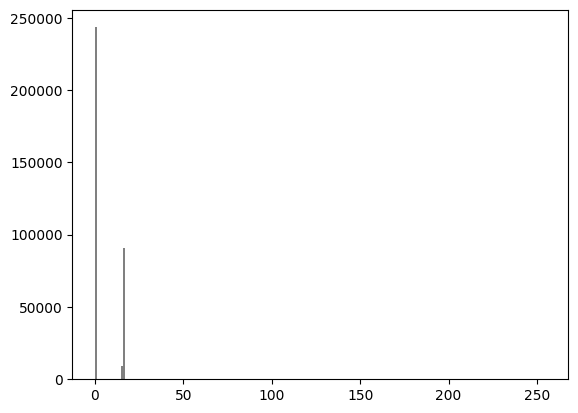

-1

In [77]:
imagen_ecualizada = np.zeros_like(imagen_color_procesada)
for y in range(h):
    for x in range(w):
        imagen_ecualizada[y,x] = 255 * FDA(numero_de_pixeles, hist, imagen[y,x])
imagen_mostrar = np.hstack((imagen_color_procesada, imagen_ecualizada))
plt.hist(imagen_ecualizada.flatten(), bins=256, range=(0,255), color="gray")
plt.show()
cv2.imshow("Imagenes", imagen_mostrar)
cv2.waitKey(0)

Procesamiento de Gamma

In [78]:
imagen_color_HSV = cv2.cvtColor(cv2.imread(ruta), cv2.COLOR_BGR2HSV)
imagen_color_HSV.shape
imagen_v = imagen_color_HSV[:,:,0]
imagen_color_HSV_procesada = contraste_brillo_mat(imagen_v, 1, 90)
imagen_color_HSV[:,:,0] = imagen_color_HSV_procesada
imagen_color_procesada = cv2.cvtColor(imagen_color_HSV, cv2.COLOR_HSV2BGR)

imagen_mostrar = np.hstack((imagen_color, imagen_color_procesada))
cv2.imshow("Imagenes", imagen_mostrar)
cv2.waitKey(0)

-1

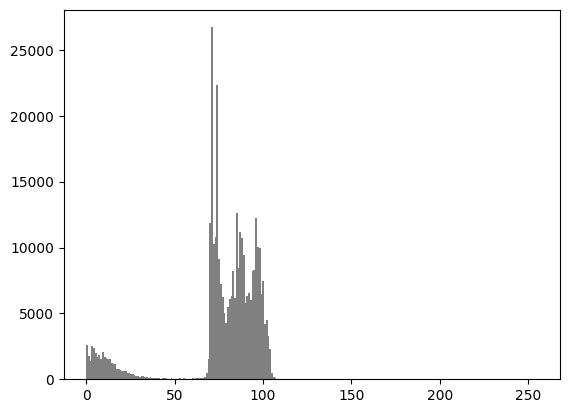

In [79]:
h, w = imagen.shape
numero_de_pixeles1 = w * h

# Funcion de distribució acumulada
def FDA(numero_de_pixeles1, hist, I):
    acum = 0
    for i in range(I):
        acum = acum + hist[i][0]
    return acum/numero_de_pixeles1

FDA(numero_de_pixeles1, hist, 128)

plt.hist(imagen_color_procesada.flatten(), bins=256, range=(0,255), color="gray")
plt.show()